In [1]:
!pip install langchain


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import getpass
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("Enter your LangChain API key: ")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "educosysGenAIclass"


In [3]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

c:\Users\Abhishek Raj\Desktop\Machine_Learning\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#dynamic query example
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to Bhojpuri. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke("what is neural network? ")
print(f"response: {ai_msg.content}")



response: A **neural network** is a computational model inspired by the structure and function of the human brain. It is a fundamental component of machine learning and artificial intelligence, designed to recognize patterns, make decisions, and solve complex problems by learning from data. Here's a structured breakdown of its key aspects:

---

### **Core Components**
1. **Neurons (Nodes):**
   - **Artificial Neurons** mimic biological neurons. Each neuron receives input signals, processes them, and produces an output.
   - **Inputs** are weighted values (numerical features or outputs from previous neurons).
   - **Weights** determine the strength of each input's influence.
   - **Bias** allows the model to adjust the output independently of inputs.
   - **Activation Function** introduces non-linearity, enabling the network to learn complex patterns. Common types include:
     - **ReLU (Rectified Linear Unit):** $ f(x) = \max(0, x) $
     - **Sigmoid:** $ f(x) = \frac{1}{1 + e^{-x}} $

In [5]:
from langchain_core.prompts import ChatPromptTemplate


travel_template="Suggest me  name of a famouse place in one word only to travel on a {location}."

prompt_template = ChatPromptTemplate.from_messages([("system",travel_template),("user","{location}")])



In [6]:
prompt=prompt_template.invoke({"location":"Patna"})
llm.invoke(prompt)

AIMessage(content='**Golghar**', additional_kwargs={'reasoning_content': 'Okay, the user is asking for a famous place in Patna that can be named in one word. Let me think about the key attractions there.\n\nPatna is a historical city in Bihar, India. Some notable places include the Patna Museum, which is a major attraction. Then there\'s the Golghar, an iconic structure. The Bodh Gaya is nearby, but it\'s a different city. The Mahabodhi Temple is in Bodh Gaya, so maybe not. The user specifically mentioned Patna, so I should focus on that.\n\nOther options could be the Raj Ghat, which is a memorial for Mahatma Gandhi. Or the Vishnupad Temple in Deoghar, but again, that\'s in a different district. The user wants a one-word name. Let me check the spelling and prominence. Patna Museum is two words. Golghar is one word and a well-known landmark. Raj Ghat is two words. The Takht Sri Patna Sahib is a significant religious site for Sikhs. That\'s one word if you consider the name. Wait, Takht 

In [7]:
prompt_template=ChatPromptTemplate.from_template("Suggest me  name of a famouse place in one word only to travel on a {country} in the month of {month}.")
prompt=prompt_template.invoke({"country":"India","month":"January"})

print(prompt)

response=llm.invoke(prompt)
response.content



messages=[HumanMessage(content='Suggest me  name of a famouse place in one word only to travel on a India in the month of January.', additional_kwargs={}, response_metadata={})]


'**Jaipur**'

## CHAINING

In [8]:
from langchain_core.output_parsers import StrOutputParser

travel_destination_chain = prompt_template | llm | StrOutputParser()

# travel_destination_chain.invoke({"country": "India", "month": "December"})

travel_itinerary_prompt = ChatPromptTemplate.from_template(
    "Give me 5 days itinerary for the place {destination}"
)

composed_chain = {"destination": travel_destination_chain} | travel_itinerary_prompt | llm | StrOutputParser()
# here the number of times llm is used is 2 times
# first to get the destination and second to get the itinerary then the final output is parsed using StrOutputParser

composed_chain.invoke({"country": "India", "month": "December"})


'Here’s a **5-day itinerary for Goa** that balances beaches, history, culture, and relaxation, with a mix of North and South Goa highlights:\n\n---\n\n### **Day 1: Arrival & North Goa Highlights**  \n**Morning:**  \n- Arrive in Goa and check into a hotel in **North Goa** (e.g., Calangute or Baga).  \n- Visit **Baga Beach** for a relaxed morning—enjoy the vibe or try water sports.  \n\n**Afternoon:**  \n- Explore **Basilica of Bom Jesus** (UNESCO World Heritage Site) in Old Goa.  \n- Stroll through **Se Cathedral** and **Church of St. Cajetan** to admire Portuguese architecture.  \n\n**Evening:**  \n- Sunset at **Sinquerim Beach** (Sinqueim).  \n- Dinner at a local seafood restaurant in **Calangute** (try Goan fish curry and prawn balchão).  \n\n---\n\n### **Day 2: South Goa & Cultural Immersion**  \n**Morning:**  \n- Drive to **South Goa** (1-hour drive).  \n- Visit **Chapora Fort** for panoramic views and the iconic sunset (famous from the movie *Goa*).  \n\n**Afternoon:**  \n- Explor

In [9]:
# Now below is the Problem 
llm.invoke(" whos is pm of india")

AIMessage(content='As of October 2023, the Prime Minister of India is **Narendra Modi**. He has been in office since May 26, 2014, and was re-elected in 2019. A member of the **Bharatiya Janata Party (BJP)**, Modi is known for his leadership in economic reforms, infrastructure development, and initiatives like "Make in India" and "Digital India." The next general election is scheduled for 2024. \n\nFor the most up-to-date information, always verify with current news sources.', additional_kwargs={'reasoning_content': "Okay, the user is asking who the Prime Minister of India is. Let me start by recalling the current political situation in India. As of my last update, Narendra Modi has been serving as the Prime Minister. He was first elected in 2014 and then re-elected in 2019. I should check if there have been any changes since then. I don't think there have been any elections since 2019, so he's likely still in office. I should also mention his party, the Bharatiya Janata Party (BJP), a

#### problem with llm by default doesnt remeber previous chat

In [10]:

# LLM bydefault does not remember the previous chat
llm.invoke("whats his age")

AIMessage(content="I don't have an age since I'm an AI language model. If you're asking about someone else's age, could you clarify who you're referring to? I'd be happy to help if you provide more context!", additional_kwargs={'reasoning_content': 'Okay, the user is asking "whats his age" but didn\'t specify who "his" refers to. I need to figure out who they\'re talking about. Let me check the conversation history.\n\nLooking back, the previous messages were about me, Qwen, and the user asked about my age. I mentioned that I don\'t have an age since I\'m an AI. Now the user is asking about "his age" again. Maybe they\'re referring to someone else mentioned earlier, but there\'s no prior context about another person. It\'s possible they\'re still talking about me, but I already answered that. Alternatively, they might be referring to a character in a story or a public figure, but without more info, it\'s hard to tell. I should ask for clarification to avoid guessing. Let me respond by 

## LangGraph


In [11]:
from langgraph.graph import StateGraph

from typing import TypedDict

class State(TypedDict):
    x: int
    y: int
    result: int

In [12]:
def func1(state):
    """Adds x and y"""
    x = state["x"]
    y = state["y"]
    result = x + y
    return {"result": result}

def func2(state):
    """Multiplies result by 2"""
    result = state["result"]
    return {"result": 2 * result}


In [13]:
# Initialize the graph with your state schema
workflow = StateGraph(State)

# Add your nodes
workflow.add_node("node_1", func1)
workflow.add_node("node_2", func2)

# Define the flow
workflow.add_edge("node_1", "node_2")

# Set where to start
workflow.set_entry_point("node_1")

# Set end point
workflow.set_finish_point("node_2")

# Compile the graph
app = workflow.compile()

In [14]:
app = workflow.compile()

result = app.invoke({"x": 5, "y": 10})
result

{'x': 5, 'y': 10, 'result': 30}

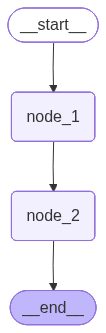

In [15]:
from IPython.display import Image, display

# Visualize the graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error displaying graph: {e}")

## Query Customer Support App


In [16]:
from typing_extensions import TypedDict, Dict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image


In [17]:
from typing import TypedDict

class State(TypedDict):
    query:str
    category:str
    sentiment:str
    response:str

llm.invoke("what is langchain in 20 words?")     

AIMessage(content='LangChain is a framework for building LLM-powered apps with modularity, integrations, and tools for data, agents, and chatbots.', additional_kwargs={'reasoning_content': 'Okay, the user is asking for a 20-word explanation of LangChain. Let me start by recalling what LangChain is. It\'s a framework for building applications with large language models. I need to mention its key features like modularity, integration with various models, and tools for data handling. Also, it\'s used for creating chatbots, agents, and more. Let me check if I can condense that into 20 words without losing the main points. Maybe start with "LangChain is a framework for building LLM-powered apps with modularity, integrations, and tools for data, agents, and chatbots." Let me count the words. That\'s 20. It covers the purpose, key aspects, and examples of applications. I think that works.\n'}, response_metadata={'token_usage': {'completion_tokens': 193, 'prompt_tokens': 18, 'total_tokens': 21

In [18]:
def categorize(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        "Categorize the following query into one of the following categories: "
        "Technical, Billing, General. Query: {query}"
    )
    chain = prompt | llm
    category = chain.invoke({"query": state["query"]}).content
    print(f"\nCategory : {category}")
    return {"category": category}


def analyze_sentiment(state: State) -> State:
    print("\nAnalyzing the sentiment : ")
    prompt = ChatPromptTemplate.from_template(
        "Analyze the sentiment of the following customer query and ans in word "
        "Response with either 'Positive', 'Neutral', or 'Negative'. Query: {query}"
    )
    chain = prompt | llm
    sentiment = chain.invoke({"query": state["query"]}).content
    print(f"\nSentiment : {sentiment}")
    return {"sentiment": sentiment}


def handle_technical(state: State) -> State:
    print("\nHandling the technical query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a technical support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def handle_billing(state: State) -> State:
    print("\nHandling the billing query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a billing support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def handle_general(state: State) -> State:
    print("\nHandling the general query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a general support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def escalate(state: State) -> State:
    print("Escalating Query")
    return {
        "response": "This query has been escalate to a human agent due to its negative sentiment"
    }
    
def route_query(state: State) -> str:  # Changed from State to str
    if state["sentiment"] == "Negative":
        return "escalate"
    elif state["category"] == "Technical":
        return "handle_technical"
    elif state["category"] == "Billing":
        return "handle_billing"
    else:
        return "handle_general"

In [19]:
workflow = StateGraph(State)

workflow.add_node("categorize", categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)

workflow.set_entry_point("categorize")

workflow.add_edge("categorize", "analyze_sentiment")

# Add conditional edges with explicit paths
workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    ["escalate", "handle_technical", "handle_billing", "handle_general"]
)

workflow.add_edge("handle_technical", END)
workflow.add_edge("handle_billing", END)
workflow.add_edge("handle_general", END)
workflow.add_edge("escalate", END)

app = workflow.compile()

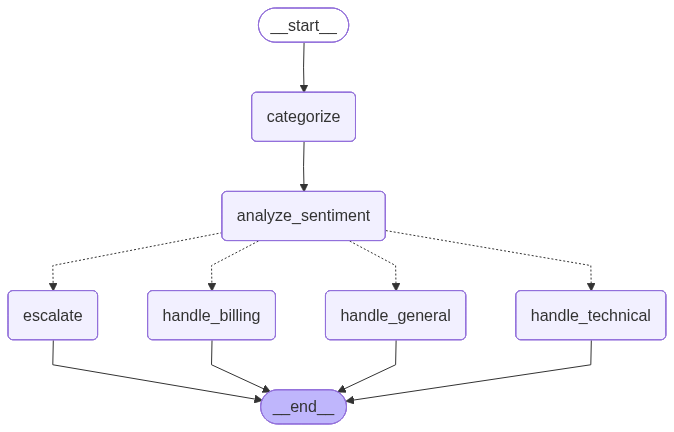

In [20]:
from IPython.display import Image, display

# Visualize the graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error displaying graph: {e}")

In [21]:
def run_customer_support(query: str) -> Dict[str, str]:
    results = app.invoke({"query": query})
    return {
        "category": results["category"],
        "sentiment": results["sentiment"],
        "response": results["response"]
    }


In [22]:
query = "The price value in my invoice is wrong"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")



Category : The query "The price value in my invoice is wrong" falls under the **Billing** category. This is because the issue pertains to the accuracy of financial information (price) on an invoice, which is directly related to billing processes. While technical errors could potentially cause such discrepancies, the user's focus is on the billing outcome rather than the underlying technical cause. 

**Category:** Billing

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: The price value in my invoice is wrong


Category: The query "The price value in my invoice is wrong" falls under the **Billing** category. This is because the issue pertains to the accuracy of financial information (price) on an invoice, which is directly related to billing processes. While technical errors could potentially cause such discrepancies, the user's focus is on the billing outcome rather than the underlying technical cause. 

**Category:** Billing


Sentiment: Nega

In [23]:
query = "my iphone isnt working"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")



Category : The query "my iPhone isn't working" falls under the **Technical** category. This is because it relates to a potential malfunction or issue with the device's functionality, which could involve hardware, software, or system-related problems.

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: my iphone isnt working


Category: The query "my iPhone isn't working" falls under the **Technical** category. This is because it relates to a potential malfunction or issue with the device's functionality, which could involve hardware, software, or system-related problems.


Sentiment: Negative


Response: This query has been escalate to a human agent due to its negative sentiment




In [24]:
query = "I purchased the iphone 16 but its screen is broken. This is not the kind of service I was expecting"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")



Category : The query is best categorized as **Technical**. The user is reporting a hardware issue (broken screen) with their iPhone 16, which falls under product functionality or quality concerns. While they mention "service," the primary issue is the defective product, making it a technical problem rather than a billing or general inquiry. 

**Answer:** Technical.

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: I purchased the iphone 16 but its screen is broken. This is not the kind of service I was expecting


Category: The query is best categorized as **Technical**. The user is reporting a hardware issue (broken screen) with their iPhone 16, which falls under product functionality or quality concerns. While they mention "service," the primary issue is the defective product, making it a technical problem rather than a billing or general inquiry. 

**Answer:** Technical.


Sentiment: Negative


Response: This query has been escalate to a hu

In [25]:
query = "I am really happy with the service and I want invoice for my new purchase"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")



Category : The query is categorized as **Billing**. The user is requesting an invoice for a new purchase, which directly relates to billing and financial transactions. The mention of being happy with the service is a general comment but does not affect the category.

Analyzing the sentiment : 

Sentiment : Positive

Handling the general query


Computed Result
Query: I am really happy with the service and I want invoice for my new purchase


Category: The query is categorized as **Billing**. The user is requesting an invoice for a new purchase, which directly relates to billing and financial transactions. The mention of being happy with the service is a general comment but does not affect the category.


Sentiment: Positive


Response: Thank you for your kind words and for choosing our service—we’re thrilled to hear you’re happy with your purchase! 🌟  

To assist you with your invoice, could you please provide the **order number** or **purchase date** associated with your transaction?

In [26]:
query = "When is the new iphone will launching?"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")



Category : The query "When is the new iPhone will launching?" is categorized as **General**. 

**Reasoning**: The question pertains to the release date of a product, which falls under general inquiry about company announcements or product availability rather than technical specifications or billing-related concerns.

Analyzing the sentiment : 

Sentiment : Positive

Handling the general query


Computed Result
Query: When is the new iphone will launching?


Category: The query "When is the new iPhone will launching?" is categorized as **General**. 

**Reasoning**: The question pertains to the release date of a product, which falls under general inquiry about company announcements or product availability rather than technical specifications or billing-related concerns.


Sentiment: Positive


Response: Apple typically launches new iPhone models in **September each year**, with the exact date often falling between **September 10th and 15th**. The official launch event is usually followe

## ChatBot

In [27]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

In [28]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

In [29]:
class State(TypedDict):
    # messages have the type "list". The add_message function
    # In the annotation defines how to handle the messages
    # (in this case appending new messages to the list)
    messages: Annotated[list[dict], add_messages]

graph_builder = StateGraph(State)    

In [30]:
def chatbot(state: State) -> State:
    return {"messages":[llm.invoke(state["messages"])]}

# first argument is the unique node name
#The second argument is the function to be executed at that node

graph_builder.add_node("chatbot_node", chatbot)

In [31]:
from langgraph.graph import START, END

graph_builder.add_edge(START,"chatbot_node")

In [32]:
graph_builder.add_edge("chatbot_node",END)

In [33]:
graph= graph_builder.compile()

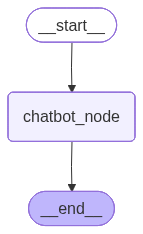

In [34]:
from IPython.display import Image, display

# Visualize the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error displaying graph: {e}")

In [ ]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content) # -1 is for the latest message


while True:
    try:
        user_input = input("User: ")

        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)

    except:
        # fallback if input() is not available (e.g., notebook environment)
        user_input = "What do you know about LangGraph?"
        print("User:", user_input)
        stream_graph_updates(user_input)
        break
    
    
    # q to quit


Goodbye!


## Memory

In [36]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [37]:
graph= graph_builder.compile(checkpointer=memory)

In [38]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]},{"configurable":{"thread_id": "1"}}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")

        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)

    except:
        # fallback if input() is not available (e.g., notebook environment)
        user_input = "What do you know about LangGraph?"
        print("User:", user_input)
        stream_graph_updates(user_input)
        break
    
    
    # q to quit


Goodbye!


In [39]:
config = {"configurable": {"thread_id": "1"}}

#### ✨✨So there is different threads to store different conversations

In [40]:
user_input = "Hi there! My name is Abhi."

# The config is the **second positional argument** to stream() or invoke()
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

Hi there! My name is Abhi.
================================== Ai Message ==================================

Hi Abhi! 😊 Nice to meet you! How can I assist you today? Whether you have questions, need help with something specific, or just want to chat, I'm here for you!


In [41]:
user_input = "do you remeber who am i??"

# The config is the **second positional argument** to stream() or invoke()
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

do you remeber who am i??
================================== Ai Message ==================================

Hi Abhi! 😊 I remember your name from our current conversation, but I don’t retain information about users or past interactions beyond the session we’re having right now. How can I assist you today? Let me know if you have questions or need help with anything! 🌟


In [42]:
config2 = {"configurable": {"thread_id": "2"}}

In [43]:
user_input = "remeber my name"

# The config is the **second positional argument** to stream() or invoke()
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config2,
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

remeber my name
================================== Ai Message ==================================

Sure! Could you please tell me your name so I can address you properly?


In [44]:
user_input = "remeber my last question"

# The config is the **second positional argument** to stream() or invoke()
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    {"configurable": {"thread_id": "3"}},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

remeber my last question
================================== Ai Message ==================================

Yes, I remember your last question! You asked about the difference between "remember" and "recall." 😊  

Would you like me to expand on that explanation, or is there something else you'd like to discuss?


### Adding tools for websearch

In [45]:
import os
import getpass
os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

In [46]:
from langchain_tavily import TavilySearch

tool = TavilySearch(
    max_results=5
)

c:\Users\Abhishek Raj\Desktop\Machine_Learning\venv\lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
c:\Users\Abhishek Raj\Desktop\Machine_Learning\venv\lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


In [53]:
tools = [tool]
tool.invoke({"query": "What happened at the last champions trophy?"})

[{'title': '2025 ICC Champions Trophy final - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/2025_ICC_Champions_Trophy_final',
  'content': 'The 2025 ICC Champions Trophy final was a One Day International (ODI) cricket match played at the Dubai International Cricket Stadium on 9 March 2025 to determine the winner of 2025 ICC Champions Trophy. It was played between India and New Zealand. It was the second time that India and New Zealand played a Champions Trophy final against each other, after the 2000 final. [...] 15. ^ "Champions Trophy: Varun Chakravarthy takes 5 wickets as India defeat New Zealand by 44 runs to set up semifinal date with Australia". The Indian Express. Retrieved 3 March 2025.\n16. ^ "IND vs AUS: Kohli leads India into fifth Champions Trophy final". Sportstar. Retrieved 4 March 2025.\n17. ^ "New Zealand Dominate Pakistan With 60-Run Win In Champions Trophy Opener". NDTV Sports. Retrieved 19 February 2025. [...] This was India\'s fifth Champions Trophy final afte

## ChatBot With memory and websearch

In [70]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# from langchain_anthropic import ChatAnthropic


# State definition -----------------------------
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]



# Graph builder -----------------------------
graph_builder = StateGraph(State)



# Tool setup -----------------------------
tool = TavilySearchResults(max_results=2)
tools = [tool] # added tool in tools list



# LLM setup with tools -----------------------------
# llm = ChatAnthropic(model="claude-3-5-sonnet-20240620")
llm_with_tools = llm.bind_tools(tools)



# Chatbot node-----------------------------
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]  }


# Nodes -----------------------------
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)


# Edges (control flow)  -----------------------------
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

# After a tool runs, go back to chatbot
graph_builder.add_edge("tools", "chatbot")

# Entry point
graph_builder.add_edge(START, "chatbot")


In [71]:
graph=graph_builder.compile(checkpointer=memory)

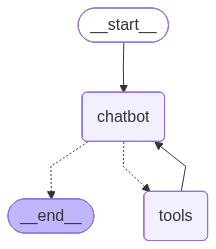

In [65]:
from IPython.display import Image, display

# Visualize the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error displaying graph: {e}")

In [ ]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]},{"configurable":{"thread_id": "4"}}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")

        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)

    except:
        # fallback if input() is not available (e.g., notebook environment)
        user_input = "What do you know about LangGraph?"
        print("User:", user_input)
        stream_graph_updates(user_input)
        break
    
    
    # q to quit


Assistant: Hello! 😊 How can I assist you today? If you have questions about **LangGraph** or anything else, feel free to ask! 🚀
Assistant: Hello again, Abhi! 😊 You mentioned your name earlier in our conversation. If you're referring to something else by "myname," feel free to clarify, and I'll do my best to help! 🌟
Assistant: The **2023 Wimbledon Championships** (the 143rd edition) took place from **July 3 to July 16, 2023**, at the All England Club in London. Here are the key highlights:

---

### **Men’s Singles Final**  
- **Novak Djokovic (Serbia)** defeated **Carlos Alcaraz (Spain)** in a thrilling 5-set match:  
  **6–2, 6–2, 6–7(5–7), 6–3**.  
- **Significance**:  
  - Djokovic claimed his **23rd Grand Slam title**, tying **Rafael Nadal** for the most men’s singles majors in history.  
  - It was Djokovic’s **first Wimbledon title since 2021** and his **third overall**.  
  - Alcaraz, the 19-year-old Spanish star, became the **youngest man to reach a Wimbledon final** since 1995